# Transformer + Multi30k

### 환경 세팅

먼저 터미널에서

`mkdir -p ~/transformer_multi30k/dataset`

`cd ~/transformer_multi30k`

`conda create -n transformer_multi30k python=3.10 -y`

`conda activate transformer_multi30k`


`conda install pytorch torchvision torchaudio pytorch-cuda=12.1 -c pytorch -c nvidia -y`

`pip install jupyterlab ipykernel spacy tqdm requests`

이거는 토크나이저임

`python -m spacy download en_core_web_sm`

`python -m spacy download fr_core_news_sm`

주피터 노트북에 현재 가상환경 커널 등록

`python -m ipykernel install --user --name=transformer_multi30k --display-name "Python (transformer_multi30k)"`

BLEU 평가용

`pip install sacrebleu`

In [1]:
!python3 -c "import sys; print('Python version:', sys.version)"

Python version: 3.10.20 (main, Mar 11 2026, 17:46:40) [GCC 14.3.0]


- Dependencies 문제가 좀 있음.

`conda install "mkl<2025" "intel-openmp<2025" -c conda-forge -y`

`conda install mkl==2024.0.0 intel-openmp==2024.0.0 -y`

In [7]:
#!conda list

In [3]:
import torch
print(torch.cuda.is_available())

True


In [4]:
!pip install datasets
!python -m spacy download de_core_news_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 kB 10.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 616.3/616.3 kB 25.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 39.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 21.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 23.5 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 25.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18/18 [datasets]/18 [datasets]ce-hub]]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.5.1 requires sympy==1.13.1, but you have sympy 1.14.0 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 21.4 MB/s  0:00:00 eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('de

In [5]:
import torch
from datasets import load_dataset

# 1. PyTorch 에러 해결 확인
print("PyTorch CUDA 사용 가능 여부:", torch.cuda.is_available())

# 2. Hugging Face에서 Multi30k (영어-독일어) 데이터셋 불러오기
print("\n데이터셋 다운로드를 시작합니다...")
dataset = load_dataset("bentrevett/multi30k")

print("\n다운로드 완료! 데이터셋 구조를 확인합니다.")
print(dataset)

# 3. 샘플 데이터 확인
print("\n" + "="*40)
print(f"English: {dataset['train'][0]['en']}")
print(f"German : {dataset['train'][0]['de']}")

/home/theo_lab/miniconda3/envs/transformer_multi30k/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch CUDA 사용 가능 여부: True

데이터셋 다운로드를 시작합니다...


Generating test split: 100%|██████████| 1000/1000 [00:00<00:00, 792874.10 examples/s]


다운로드 완료! 데이터셋 구조를 확인합니다.
DatasetDict({
    train: Dataset({
        features: ['en', 'de'],
        num_rows: 29000
    })
    validation: Dataset({
        features: ['en', 'de'],
        num_rows: 1014
    })
    test: Dataset({
        features: ['en', 'de'],
        num_rows: 1000
    })
})

English: Two young, White males are outside near many bushes.
German : Zwei junge weiße Männer sind im Freien in der Nähe vieler Büsche.


### 단어 사전(Vocabulary)과 DataLoader 구축

In [6]:
import torch
import spacy
from collections import Counter
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

# 1. Spacy 토크나이저 로드
spacy_de = spacy.load("de_core_news_sm")
spacy_en = spacy.load("en_core_web_sm")

def tokenize_de(text):
    return [tok.text.lower() for tok in spacy_de.tokenizer(text)]

def tokenize_en(text):
    return [tok.text.lower() for tok in spacy_en.tokenizer(text)]

# 2. 특수 토큰 정의 (컴퓨터가 문장의 시작과 끝, 빈칸을 알게 함)
UNK_IDX, PAD_IDX, BOS_IDX, EOS_IDX = 0, 1, 2, 3
special_symbols = ['<unk>', '<pad>', '<bos>', '<eos>']

# 3. 단어 사전(Vocabulary) 구축 함수
def build_vocab(data_split, tokenize_fn, lang, min_freq=2):
    counter = Counter()
    for item in data_split:
        counter.update(tokenize_fn(item[lang]))
    
    # 특수 토큰을 먼저 사전에 넣음
    vocab = {sym: idx for idx, sym in enumerate(special_symbols)}
    
    # 최소 등장 빈도(min_freq)를 넘는 단어만 사전에 추가
    for word, freq in counter.items():
        if freq >= min_freq and word not in vocab:
            vocab[word] = len(vocab)
    return vocab

print("단어 사전을 구축하는 중입니다. (약 10~20초 소요)...")
vocab_src = build_vocab(dataset['train'], tokenize_en, 'en')
vocab_tgt = build_vocab(dataset['train'], tokenize_de, 'de')

print(f"영어(Source) 단어 사전 크기: {len(vocab_src)}")
print(f"독일어(Target) 단어 사전 크기: {len(vocab_tgt)}")

# 4. 문장을 숫자로 이루어진 텐서로 변환하는 함수
def text_transform(text, tokenize_fn, vocab):
    tokens = tokenize_fn(text)
    # 사전에 없으면 <unk> (0) 처리
    token_ids = [vocab.get(token, UNK_IDX) for token in tokens]
    # 문장 앞뒤로 <bos>와 <eos> 추가
    return [BOS_IDX] + token_ids + [EOS_IDX]

# 5. Dataloader가 배치를 만들 때 데이터를 묶어주는 함수
def collate_fn(batch):
    src_batch, tgt_batch = [], []
    for item in batch:
        src_ids = text_transform(item['en'], tokenize_en, vocab_src)
        tgt_ids = text_transform(item['de'], tokenize_de, vocab_tgt)
        src_batch.append(torch.tensor(src_ids, dtype=torch.long))
        tgt_batch.append(torch.tensor(tgt_ids, dtype=torch.long))
    
    # 길이가 다른 문장들을 가장 긴 문장 길이에 맞춰 <pad> 토큰으로 채움
    src_batch = pad_sequence(src_batch, padding_value=PAD_IDX, batch_first=True)
    tgt_batch = pad_sequence(tgt_batch, padding_value=PAD_IDX, batch_first=True)
    return src_batch, tgt_batch

# 6. DataLoader 생성 (VRAM이 넉넉하므로 128 배치 사용)
BATCH_SIZE = 128
train_dataloader = DataLoader(dataset['train'], batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
valid_dataloader = DataLoader(dataset['validation'], batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print("\nDataLoader 준비 완료!")
for src, tgt in train_dataloader:
    print(f"첫 번째 배치 Source(영어) 텐서 크기: {src.shape}")
    print(f"첫 번째 배치 Target(독일어) 텐서 크기: {tgt.shape}")
    break

단어 사전을 구축하는 중입니다. (약 10~20초 소요)...
영어(Source) 단어 사전 크기: 5893
독일어(Target) 단어 사전 크기: 7853

DataLoader 준비 완료!
첫 번째 배치 Source(영어) 텐서 크기: torch.Size([128, 36])
첫 번째 배치 Target(독일어) 텐서 크기: torch.Size([128, 33])


In [8]:
import torch
import torch.nn as nn
import math

# 1. Multi-Head Attention (스스로 문맥을 파악하는 심장부)
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model은 num_heads로 나누어 떨어져야 합니다."
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        
    def forward(self, query, key, value, mask=None):
        batch_size = query.size(0)
        
        # (Batch, Seq_Len, d_model) -> (Batch, Num_Heads, Seq_Len, d_k)로 변환
        Q = self.W_q(query).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(key).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(value).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        
        # Scaled Dot-Product Attention 계산
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
            
        attention = torch.softmax(scores, dim=-1)
        x = torch.matmul(attention, V)
        
        # 다시 원래 차원으로 복구
        x = x.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        return self.W_o(x)

# 2. Position-wise Feed-Forward Network (GELU 적용)
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.activation = nn.GELU() # ReLU 대신 모던한 GELU 사용

    def forward(self, x):
        return self.linear2(self.dropout(self.activation(self.linear1(x))))

# 3. Encoder Layer (Pre-LN 구조 적용)
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_mask):
        # Pre-LN: 정규화를 먼저 하고 Attention 적용
        nx = self.norm1(x)
        x = x + self.dropout(self.self_attn(nx, nx, nx, src_mask))
        nx = self.norm2(x)
        x = x + self.dropout(self.ffn(nx))
        return x

# 4. Decoder Layer (Pre-LN 구조 적용)
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff, dropout)
        
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, src_mask, tgt_mask):
        nx = self.norm1(x)
        x = x + self.dropout(self.self_attn(nx, nx, nx, tgt_mask))
        
        nx = self.norm2(x)
        x = x + self.dropout(self.cross_attn(nx, enc_output, enc_output, src_mask))
        
        nx = self.norm3(x)
        x = x + self.dropout(self.ffn(nx))
        return x

# 5. 최종 Seq2Seq Transformer 통합 모델
class Seq2SeqTransformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=256, num_heads=8, num_layers=3, d_ff=512, max_len=5000, dropout=0.1):
        super().__init__()
        # 임베딩 & 위치 인코딩 (모던하게 nn.Embedding 활용)
        self.src_emb = nn.Embedding(src_vocab_size, d_model)
        self.tgt_emb = nn.Embedding(tgt_vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)
        
        self.encoder_layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.decoder_layers = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        
        self.fc_out = nn.Linear(d_model, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout)
        self.scale = math.sqrt(d_model)

    def create_position_ids(self, x):
        batch_size, seq_len = x.size()
        return torch.arange(0, seq_len).unsqueeze(0).expand(batch_size, seq_len).to(x.device)

    def encode(self, src, src_mask):
        pos = self.create_position_ids(src)
        x = self.dropout((self.src_emb(src) * self.scale) + self.pos_emb(pos))
        for layer in self.encoder_layers:
            x = layer(x, src_mask)
        return x

    def decode(self, tgt, enc_output, src_mask, tgt_mask):
        pos = self.create_position_ids(tgt)
        x = self.dropout((self.tgt_emb(tgt) * self.scale) + self.pos_emb(pos))
        for layer in self.decoder_layers:
            x = layer(x, enc_output, src_mask, tgt_mask)
        return self.fc_out(x)

    def forward(self, src, tgt, src_mask, tgt_mask):
        enc_output = self.encode(src, src_mask)
        output = self.decode(tgt, enc_output, src_mask, tgt_mask)
        return output

# 모델 인스턴스화 및 텐서 플로우 테스트
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Seq2SeqTransformer(
    src_vocab_size=len(vocab_src), 
    tgt_vocab_size=len(vocab_tgt)
).to(device)

print(f"모델 파라미터 수: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}개")

모델 파라미터 수: 10,770,861개


In [9]:
import time

# 1. 마스크 생성 함수
def create_masks(src, tgt):
    # src: (Batch, Src_Len), tgt: (Batch, Tgt_Len)
    
    # 1-1. Source Mask: <pad>가 아닌 부분만 1(True)로 설정
    src_mask = (src != PAD_IDX).unsqueeze(1).unsqueeze(2) # (Batch, 1, 1, Src_Len)
    
    # 1-2. Target Pad Mask: <pad>가 아닌 부분 1로 설정
    tgt_pad_mask = (tgt != PAD_IDX).unsqueeze(1).unsqueeze(2) # (Batch, 1, 1, Tgt_Len)
    
    # 1-3. Target Causal Mask: 미래 단어를 못 보게 하단 삼각형 행렬 생성
    tgt_len = tgt.size(1)
    causal_mask = torch.tril(torch.ones((tgt_len, tgt_len), device=src.device)).bool()
    
    # 두 조건을 동시에 만족해야 함 (& 연산자)
    tgt_mask = tgt_pad_mask & causal_mask 
    
    return src_mask, tgt_mask

# 2. 손실 함수와 옵티마이저 설정
# Label Smoothing 0.1을 주어 정답에 대한 과도한 확신을 방지 (원논문 기법) [cite: 17, 20, 26]
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=0.1)

# 모던 딥러닝에서 주로 쓰는 AdamW 사용 (일반화 성능 향상)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.01)

# 3. 1 에포크 학습 함수
def train_epoch(model, dataloader, optimizer, criterion):
    model.train()
    total_loss = 0
    
    for src, tgt in dataloader:
        src = src.to(device)
        tgt = tgt.to(device)
        
        # 디코더의 입력(tgt_input)과 모델이 맞춰야 할 정답(tgt_expected)을 분리
        # 예: <bos> I love you <eos>
        # 입력: <bos> I love you
        # 정답: I love you <eos>
        tgt_input = tgt[:, :-1]
        tgt_expected = tgt[:, 1:]
        
        src_mask, tgt_mask = create_masks(src, tgt_input)
        
        optimizer.zero_grad()
        # 모델 예측 (Forward)
        output = model(src, tgt_input, src_mask, tgt_mask)
        
        # CrossEntropyLoss 계산을 위해 차원 평탄화
        output = output.reshape(-1, output.shape[-1])
        tgt_expected = tgt_expected.reshape(-1)
        
        loss = criterion(output, tgt_expected)
        
        # 오차 역전파 및 가중치 업데이트 (Backward)
        loss.backward()
        # Gradient Clipping: 기울기 폭발 방지
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        
    return total_loss / len(dataloader)

# 4. 평가 함수
def evaluate(model, dataloader, criterion):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for src, tgt in dataloader:
            src = src.to(device)
            tgt = tgt.to(device)
            
            tgt_input = tgt[:, :-1]
            tgt_expected = tgt[:, 1:]
            
            src_mask, tgt_mask = create_masks(src, tgt_input)
            output = model(src, tgt_input, src_mask, tgt_mask)
            
            output = output.reshape(-1, output.shape[-1])
            tgt_expected = tgt_expected.reshape(-1)
            
            loss = criterion(output, tgt_expected)
            total_loss += loss.item()
            
    return total_loss / len(dataloader)

# 테스트용 1 Epoch 실행
print("1 Epoch 학습을 시작합니다. VRAM과 속도를 점검해 보세요!")
start_time = time.time()
train_loss = train_epoch(model, train_dataloader, optimizer, criterion)
valid_loss = evaluate(model, valid_dataloader, criterion)
end_time = time.time()

print(f"소요 시간: {end_time - start_time:.2f}초")
print(f"Train Loss: {train_loss:.4f} | Valid Loss: {valid_loss:.4f}")

1 Epoch 학습을 시작합니다. VRAM과 속도를 점검해 보세요!
소요 시간: 14.45초
Train Loss: 12.9006 | Valid Loss: 6.5059


In [11]:
import os
import math
from pathlib import Path

# 1. 하이퍼파라미터 설정
EPOCHS = 20
best_valid_loss = float('inf')

print(f"총 {EPOCHS} 에포크 학습을 시작합니다...\n" + "="*40)

for epoch in range(EPOCHS):
    start_time = time.time()
    
    # 앞서 정의한 train_epoch와 evaluate 함수 사용
    train_loss = train_epoch(model, train_dataloader, optimizer, criterion)
    valid_loss = evaluate(model, valid_dataloader, criterion)
    
    end_time = time.time()
    epoch_mins, epoch_secs = divmod(end_time - start_time, 60)
    
    # 아까 만들어둔 dataset 폴더 경로 재사용
    SAVE_DIR = Path(os.path.expanduser('~/transformer_multi30k/dataset'))
    MODEL_SAVE_PATH = SAVE_DIR / 'transformer_multi30k_best.pt'

    # (학습 루프 안에서 저장하는 부분)
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        # 지정한 경로에 저장하도록 변경!
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        mark = " (Best Model Saved!)"
    else:
        mark = ""
        
    print(f'Epoch: {epoch+1:02} | Time: {int(epoch_mins)}m {int(epoch_secs)}s' + mark)
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')

# =====================================================================

# 2. 번역 추론 (Inference) 함수 정의 - Greedy Decoding 방식
def translate_sentence(sentence, model, spacy_en, vocab_src, vocab_tgt, max_len=50):
    model.eval()
    
    # 입력 문장 토큰화 및 텐서 변환
    if isinstance(sentence, str):
        tokens = [tok.text.lower() for tok in spacy_en.tokenizer(sentence)]
    else:
        tokens = [token.lower() for token in sentence]
        
    src_indexes = [BOS_IDX] + [vocab_src.get(token, UNK_IDX) for token in tokens] + [EOS_IDX]
    src_tensor = torch.tensor(src_indexes, dtype=torch.long).unsqueeze(0).to(device)
    
    # Source Mask 생성
    src_mask = (src_tensor != PAD_IDX).unsqueeze(1).unsqueeze(2).to(device)
    
    with torch.no_grad():
        # 인코더를 한 번만 통과시킴
        enc_output = model.encode(src_tensor, src_mask)
        
    # 디코더의 첫 입력은 항상 <bos> 토큰
    tgt_indexes = [BOS_IDX]
    
    # 디코더를 반복적으로 실행하며 다음 단어를 예측 (Greedy 방식)
    for i in range(max_len):
        tgt_tensor = torch.tensor(tgt_indexes, dtype=torch.long).unsqueeze(0).to(device)
        tgt_mask = create_masks(src_tensor, tgt_tensor)[1].to(device)
        
        with torch.no_grad():
            output = model.decode(tgt_tensor, enc_output, src_mask, tgt_mask)
            
        # 가장 확률이 높은 다음 단어 선택
        pred_token = output.argmax(2)[:, -1].item()
        tgt_indexes.append(pred_token)
        
        # 만약 <eos> 토큰을 예측했다면 문장 생성 종료
        if pred_token == EOS_IDX:
            break
            
    # 숫자(Index)를 다시 텍스트(단어)로 변환
    idx_to_word = {idx: word for word, idx in vocab_tgt.items()}
    translated_words = [idx_to_word.get(idx, '<unk>') for idx in tgt_indexes]
    
    # <bos>와 <eos> 제외하고 반환
    return " ".join(translated_words[1:-1])

# =====================================================================

# 3. 학습된 최고 성능 모델 불러오기 및 테스트
print("\n" + "="*40 + "\n학습 완료! 최고 성능 모델을 불러와 번역 테스트를 진행합니다.")
model.load_state_dict(torch.load(MODEL_SAVE_PATH, weights_only=True))

# 테스트 문장들 (실제 훈련에 사용되지 않은 문장들)
test_sentences = [
    "Two young, White males are outside near many bushes.",
    "A dog is running on the grass.",
    "A woman is playing the guitar.",
]

for sentence in test_sentences:
    translation = translate_sentence(sentence, model, spacy_en, vocab_src, vocab_tgt)
    print(f"\n입력(Eng): {sentence}")
    print(f"출력(Ger): {translation}")

총 20 에포크 학습을 시작합니다...
Epoch: 01 | Time: 0m 14s (Best Model Saved!)
	Train Loss: 2.556 | Train PPL:  12.878
	 Val. Loss: 3.240 |  Val. PPL:  25.525
Epoch: 02 | Time: 0m 14s (Best Model Saved!)
	Train Loss: 2.527 | Train PPL:  12.521
	 Val. Loss: 3.227 |  Val. PPL:  25.206
Epoch: 03 | Time: 0m 14s
	Train Loss: 2.499 | Train PPL:  12.176
	 Val. Loss: 3.228 |  Val. PPL:  25.241
Epoch: 04 | Time: 0m 14s (Best Model Saved!)
	Train Loss: 2.477 | Train PPL:  11.910
	 Val. Loss: 3.222 |  Val. PPL:  25.081
Epoch: 05 | Time: 0m 14s (Best Model Saved!)
	Train Loss: 2.455 | Train PPL:  11.647
	 Val. Loss: 3.219 |  Val. PPL:  24.993
Epoch: 06 | Time: 0m 14s (Best Model Saved!)
	Train Loss: 2.432 | Train PPL:  11.382
	 Val. Loss: 3.217 |  Val. PPL:  24.946
Epoch: 07 | Time: 0m 14s (Best Model Saved!)
	Train Loss: 2.409 | Train PPL:  11.121
	 Val. Loss: 3.213 |  Val. PPL:  24.853
Epoch: 08 | Time: 0m 14s (Best Model Saved!)
	Train Loss: 2.387 | Train PPL:  10.876
	 Val. Loss: 3.204 |  Val. PPL:  24.62

- BLEU 평가하기

In [13]:
import sacrebleu
from tqdm.auto import tqdm

# 1. 평가할 테스트 데이터 준비
test_data = dataset['test']
predictions = []
references = []

print(f"총 {len(test_data)}개의 테스트 문장 번역 및 BLEU 스코어 계산을 시작합니다...")

# 2. 1000개의 문장을 하나씩 번역 (진행률 바 표시)
for example in tqdm(test_data):
    src_text = example['en']
    tgt_text = example['de']  # 인간이 번역한 정답 문장
    
    # 모델을 통해 예측 번역 수행
    pred_text = translate_sentence(src_text, model, spacy_en, vocab_src, vocab_tgt)
    
    predictions.append(pred_text)
    references.append(tgt_text)

# 3. SacreBLEU를 이용한 최종 점수 계산
# 예측된 문장들의 구두점 띄어쓰기를 자연스럽게 붙여줌 (간단한 Detokenization)
clean_predictions = [pred.replace(" .", ".").replace(" ,", ",") for pred in predictions]

# 대소문자를 무시하고(lowercase=True) 다시 BLEU 스코어 계산
bleu = sacrebleu.corpus_bleu(clean_predictions, [references], lowercase=True)

print("\n" + "="*40)
print(f"🎉 제대로 채점된 최종 BLEU Score: {bleu.score:.2f}")
print("="*40)
print("\n" + "="*40)
print(f"🎉 최종 BLEU Score: {bleu.score:.2f}")
print("="*40)

총 1000개의 테스트 문장 번역 및 BLEU 스코어 계산을 시작합니다...


100%|██████████| 1000/1000 [00:15<00:00, 65.59it/s]


🎉 제대로 채점된 최종 BLEU Score: 21.94

🎉 최종 BLEU Score: 21.94


입력: A dog is running on the grass.
번역: ein hund rennt auf dem gras .


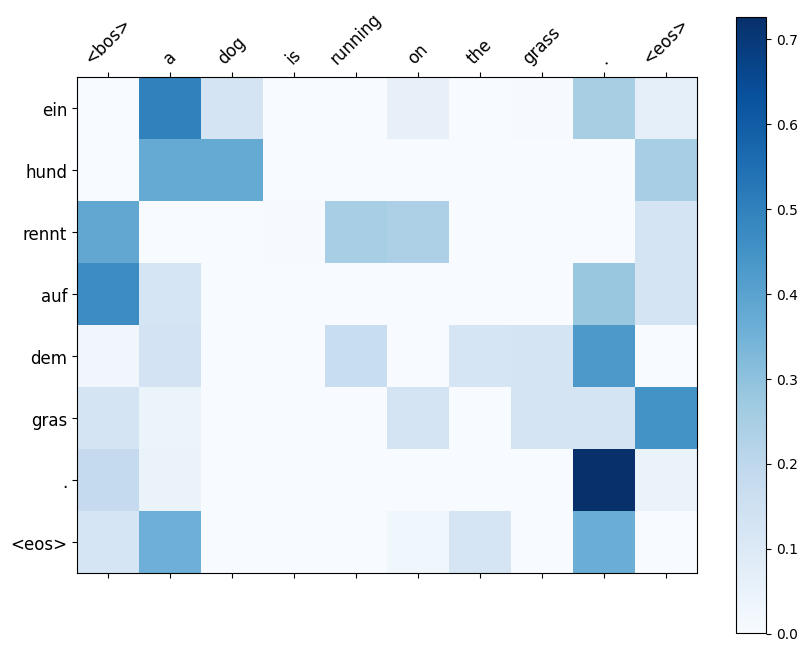

In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# 1. 어텐션 맵 추출용 추론 함수 (기존 모델 구조 해킹(?) 없이 가중치만 추출)
def translate_and_get_attention(sentence, model, spacy_en, vocab_src, vocab_tgt, max_len=50):
    model.eval()
    
    # 입력 문장 토큰화
    if isinstance(sentence, str):
        tokens = [tok.text.lower() for tok in spacy_en.tokenizer(sentence)]
    else:
        tokens = [token.lower() for token in sentence]
        
    src_indexes = [BOS_IDX] + [vocab_src.get(token, UNK_IDX) for token in tokens] + [EOS_IDX]
    src_tensor = torch.tensor(src_indexes, dtype=torch.long).unsqueeze(0).to(device)
    src_mask = (src_tensor != PAD_IDX).unsqueeze(1).unsqueeze(2).to(device)
    
    with torch.no_grad():
        enc_output = model.encode(src_tensor, src_mask)
        
    tgt_indexes = [BOS_IDX]
    
    for i in range(max_len):
        tgt_tensor = torch.tensor(tgt_indexes, dtype=torch.long).unsqueeze(0).to(device)
        tgt_mask = create_masks(src_tensor, tgt_tensor)[1].to(device)
        
        with torch.no_grad():
            # 디코더의 마지막 출력까지 수동으로 추적하여 Cross-Attention 값을 빼냄
            dec_output = model.dropout((model.tgt_emb(tgt_tensor) * model.scale) + model.pos_emb(model.create_position_ids(tgt_tensor)))
            
            for layer in model.decoder_layers:
                nx = layer.norm1(dec_output)
                dec_output = dec_output + layer.dropout(layer.self_attn(nx, nx, nx, tgt_mask))
                
                nx = layer.norm2(dec_output)
                
                # ------ [핵심] 여기서 Cross-Attention 가중치 훔쳐오기 ------
                cross_attn = layer.cross_attn
                batch_size = nx.size(0)
                Q = cross_attn.W_q(nx).view(batch_size, -1, cross_attn.num_heads, cross_attn.d_k).transpose(1, 2)
                K = cross_attn.W_k(enc_output).view(batch_size, -1, cross_attn.num_heads, cross_attn.d_k).transpose(1, 2)
                
                scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(cross_attn.d_k)
                scores = scores.masked_fill(src_mask == 0, -1e9)
                attention_weights = torch.softmax(scores, dim=-1)
                
                V = cross_attn.W_v(enc_output).view(batch_size, -1, cross_attn.num_heads, cross_attn.d_k).transpose(1, 2)
                x = torch.matmul(attention_weights, V)
                x = x.transpose(1, 2).contiguous().view(batch_size, -1, cross_attn.d_model)
                x = cross_attn.W_o(x)
                # -------------------------------------------------------------
                
                dec_output = dec_output + layer.dropout(x)
                nx = layer.norm3(dec_output)
                dec_output = dec_output + layer.dropout(layer.ffn(nx))
                
        pred_token = model.fc_out(dec_output).argmax(2)[:, -1].item()
        tgt_indexes.append(pred_token)
        
        if pred_token == EOS_IDX:
            break
            
    idx_to_word_tgt = {idx: word for word, idx in vocab_tgt.items()}
    translated_words = [idx_to_word_tgt.get(idx, '<unk>') for idx in tgt_indexes]
    
    # 마지막 시점(전체 문장 생성 완료 후)의 어텐션 가중치 중 8개 헤드의 평균값을 반환
    final_attention = attention_weights[0].mean(dim=0).cpu().numpy()
    
    return translated_words[1:], tokens, final_attention

# 2. 어텐션 맵 시각화 (히트맵) 함수
def display_attention(sentence_tokens, translation_words, attention):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111)
    
    # 파란색이 짙을수록 해당 단어에 집중했다는 뜻
    cax = ax.matshow(attention, cmap='Blues')
    
    # 축 설정
    src_labels = ['<bos>'] + sentence_tokens + ['<eos>']
    ax.set_xticks(range(len(src_labels)))
    ax.set_xticklabels(src_labels, rotation=45, fontsize=12)
    
    tgt_labels = translation_words
    ax.set_yticks(range(len(tgt_labels)))
    ax.set_yticklabels(tgt_labels, fontsize=12)
    
    plt.colorbar(cax)
    plt.show()

# 3. 테스트!
sentence = "A dog is running on the grass."
translation, tokens, attention_map = translate_and_get_attention(sentence, model, spacy_en, vocab_src, vocab_tgt)

print(f"입력: {sentence}")
print(f"번역: {' '.join(translation[:-1])}")
display_attention(tokens, translation, attention_map)

독일어 단어인 hund(개)를 출력할 때 영어의 dog 부분 칸이 짙은 파란색이면 제대로 이해하고 있는거임.